[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pabanib/Clases_clasificacion/blob/main/07_clustering_practico.ipynb#copy=true)


[![Open in Anaconda](https://static.anaconda.cloud/content/a22d04e8445b700f28937ab3231b8cded505d0395c63b7a269696722196d5415)](https://anaconda.com/api/nbserve/launch_notebook?nb_url=https%3A%2F%2Fanaconda.com%2Fapi%2Fprojects%2F6905e11d-e422-418c-ad09-bff2871f164e%2Ffiles%2F06_clustering_teorico.ipynb%3Fversion%3Dffb0e57f-f271-48c3-8c7f-226801965a08)



# Modelos no supervisados: Clustering


Las técnicas de clustering son variadas y nos permiten determinar patrones de agrupamientos que no son fácilmente observables.

A continuación se va tratar de segmentar clientes de compra online. El dataframe es obtenido de la siguiente dirección: https://archive.ics.uci.edu/dataset/352/online+retail. Aunque de ahí se transformado las variables para dejarlo a nivel cliente.




In [37]:
import pandas as pd
import sklearn.cluster as cl
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import plotly.express as px

In [38]:
ventas = pd.read_csv("https://raw.githubusercontent.com/pabanib/dataframes/master/online_retail.csv")
ventas.head()

,CustomerID,total_monto,total_cantidades,distintos_productos,cantidad_operaciones,hora_mas_frecuente,repitio_mismo_dia,producto_mas_comprado,Country
0,12347.0,4310.00,2458,103,7,14,False,23076 - ICE CREAM SUNDAE LIP GLOSS,Iceland
1,12348.0,1797.24,2341,22,4,10,False,23077 - DOUGHNUT LIP GLOSS,Finland
2,12349.0,1757.55,631,73,1,9,False,21231 - SWEETHEART CERAMIC TRINKET BOX,Italy
3,12350.0,334.40,197,17,1,16,False,22348 - TEA BAG PLATE RED RETROSPOT,Norway
4,12352.0,1545.41,470,59,11,14,True,84050 - PINK HEART SHAPE EGG FRYING PAN,Norway


## Descripción de las variables de `online_retail`

El dataframe reúne información del comportamiento de compra de cada cliente durante el período analizado.

| Columna | Descripción | Tipo de variable |
|---|---|---|
| `CustomerID` | Identificador único del cliente. Aunque aparece como número, se utiliza para identificarlo y no representa una cantidad. | Categórica nominal — identificador. |
| `total_monto` | Importe total de las compras registradas para el cliente durante el período analizado. Representa su aporte a la facturación, no la ganancia que genera. | Cuantitativa continua. |
| `total_cantidades` | Cantidad total de unidades compradas por el cliente. Incluye varias unidades de un mismo producto. | Cuantitativa discreta. |
| `distintos_productos` | Cantidad de productos diferentes comprados por el cliente. Describe la variedad de su compra, independientemente de cuántas unidades adquirió de cada producto. | Cuantitativa discreta. |
| `cantidad_operaciones` | Número de operaciones de compra registradas para el cliente durante el período analizado. Permite describir su frecuencia de compra. | Cuantitativa discreta. |
| `hora_mas_frecuente` | Hora del día en la que el cliente registra compras con mayor frecuencia. Se expresa en formato de 24 horas y tiene un comportamiento cíclico: después de las 23 comienza nuevamente la hora 0. | Temporal cíclica. |
| `repitio_mismo_dia` | Indicador de si el cliente realizó más de una operación de compra en una misma fecha. Toma el valor `True` cuando ocurrió y `False` cuando no ocurrió. | Categórica binaria. |
| `producto_mas_comprado` | Producto identificado como el más comprado por el cliente. El campo contiene el código y la descripción del producto. | Categórica nominal. |
| `Country` | País asociado al cliente en los registros de compra. | Categórica nominal. |

**Diferencia entre unidades, productos y operaciones:** si un cliente realiza dos pedidos y en cada uno compra tres unidades del mismo producto, acumula seis unidades, un producto distinto y dos operaciones.

# Análisis exploratorio de los datos


In [39]:
ventas.dtypes

CustomerID               float64
total_monto              float64
total_cantidades           int64
distintos_productos        int64
cantidad_operaciones       int64
hora_mas_frecuente         int64
repitio_mismo_dia           bool
producto_mas_comprado     object
Country                   object
dtype: object

#### País del consumidor

<Axes: xlabel='Country'>

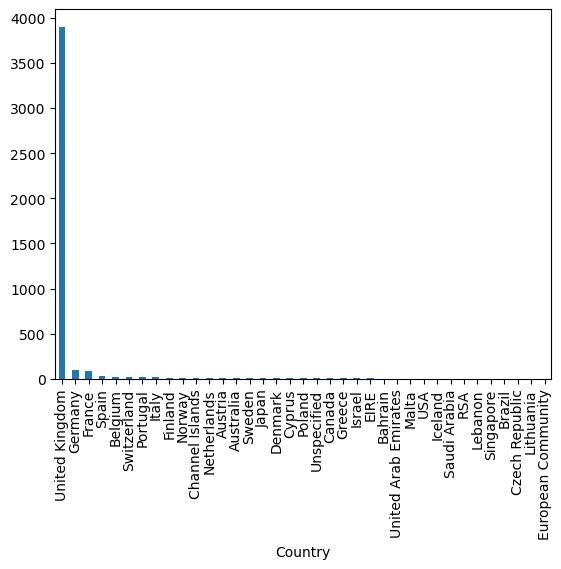

In [40]:
ventas.Country.value_counts().plot(kind = 'bar')

Como la gran mayoría de los clientes son del Reino Unido, vamos convertir esta variable en una dicotómica: 1 si pertenece a UK y 0 en caso contrario

In [41]:
ventas['UK'] = ventas.Country.apply(lambda x: 1 if x == 'United Kingdom' else 0)

#### Producto más comprado

En cada operación el cliente puede ejecutar la compra de diversos productos. Para unirlos en un cliente se coloca el producto que el cliente más compra.

In [42]:
ventas.producto_mas_comprado.value_counts()

producto_mas_comprado
84077 - WORLD WAR 2 GLIDERS ASSTD DESIGNS      129
84879 - ASSORTED COLOUR BIRD ORNAMENT           78
22492 - MINI PAINT SET VINTAGE                  71
85123A - WHITE HANGING HEART T-LIGHT HOLDER     56
85099B - JUMBO BAG RED RETROSPOT                50
                                              ... 
22614 - PACK OF 12 SPACEBOY TISSUES              1
84992 - 72 SWEETHEART FAIRY CAKE CASES           1
20837 - FRENCH FLORAL CUSHION COVER              1
21933 - PINK VINTAGE PAISLEY PICNIC BAG          1
22482 - BLUE TEA TOWEL CLASSIC DESIGN            1
Name: count, Length: 1094, dtype: int64

En este caso, también nos vamos a quedar con los 4 productos más que son los más elegidos por los consumidores. Creamos una variable dummy por cada uno de ellos

In [43]:
l = ventas.producto_mas_comprado.value_counts()[:4].index
for p in l:
    ventas[p] = ventas.producto_mas_comprado.apply(lambda x: 1 if x == p else 0)

ventas[l]

,84077 - WORLD WAR 2 GLIDERS ASSTD DESIGNS,84879 - ASSORTED COLOUR BIRD ORNAMENT,22492 - MINI PAINT SET VINTAGE,85123A - WHITE HANGING HEART T-LIGHT HOLDER
0,0,0,0,0
1,0,0,0,0
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0
...,...,...,...,...
4312,0,0,0,0
4313,0,0,0,0
4314,0,0,0,0
4315,0,0,0,0


#### Promedios

Agregamos los promedios de gasto total que tiene el cliente por cada  orden que ejecuta y la cantidad de unidades promedio también.

In [44]:
ventas['gasto_prom_operacion'] = ventas.total_monto/ventas.cantidad_operaciones
ventas['cant_prom_operacion'] = ventas.total_cantidades/ventas.cantidad_operaciones


In [45]:
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4317 entries, 0 to 4316
Data columns (total 16 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   CustomerID                                   4317 non-null   float64
 1   total_monto                                  4317 non-null   float64
 2   total_cantidades                             4317 non-null   int64  
 3   distintos_productos                          4317 non-null   int64  
 4   cantidad_operaciones                         4317 non-null   int64  
 5   hora_mas_frecuente                           4317 non-null   int64  
 6   repitio_mismo_dia                            4317 non-null   bool   
 7   producto_mas_comprado                        4317 non-null   object 
 8   Country                                      4317 non-null   object 
 9   UK                                           4317 non-null   int64  
 10  

<Axes: xlabel='gasto_prom_operacion', ylabel='distintos_productos'>

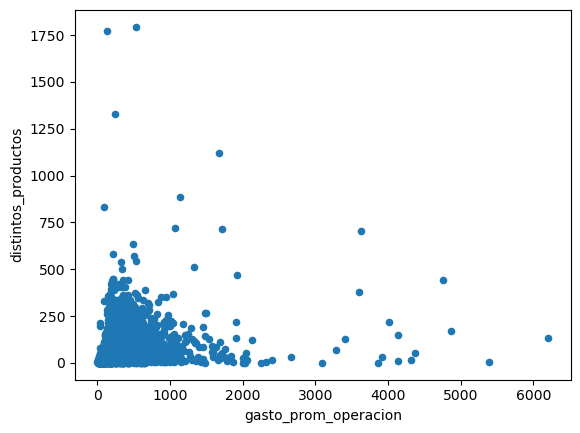

In [46]:
ventas.plot(kind= 'scatter', x = 'gasto_prom_operacion', y = 'distintos_productos')

<Axes: >

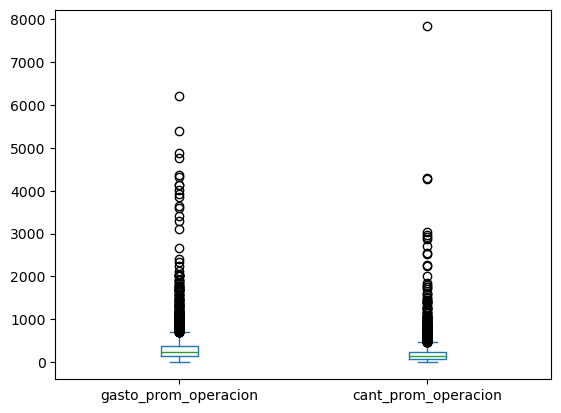

In [47]:
ventas[['gasto_prom_operacion', 'cant_prom_operacion']].plot(kind='box')

In [48]:
ventas[['gasto_prom_operacion', 'cant_prom_operacion']].describe()

,gasto_prom_operacion,cant_prom_operacion
count,4317.000000,4317.000000
mean,322.524003,196.686504
std,351.448673,261.751677
min,0.966667,0.000000
25%,154.680000,79.500000
50%,240.025000,139.000000
75%,372.728571,233.478261
max,6207.670000,7824.000000


Ambos promedios muestras datos muy atípicos. Estos se deben a clientes grandes probablemente. Para realizar un mejor clustering conviene elimiar estos extremos para que no afecte a la función.

Todo valor que esté por encima de del percentil 90 lo vamos a considerar extremo.

In [49]:
gpo_v_ext = ventas.gasto_prom_operacion.quantile([0.90]).values[0]
cpo_v_ext = ventas.cant_prom_operacion.quantile([0.90]).values[0]

ventas2 = ventas[(ventas.gasto_prom_operacion < gpo_v_ext) & (ventas.cant_prom_operacion < cpo_v_ext)]

ventas2[['gasto_prom_operacion', 'cant_prom_operacion']].describe()

,gasto_prom_operacion,cant_prom_operacion
count,3755.000000,3755.000000
mean,238.222081,137.328956
std,121.222626,81.670340
min,0.966667,0.000000
25%,145.718500,73.000000
50%,214.927500,124.100000
75%,318.212500,190.000000
max,581.725000,366.000000


In [50]:
def momento_dia(hora):
    if hora < 6:
        return 'madrugada'
    elif hora < 12:
        return 'mañana'
    elif hora < 18:
        return 'tarde'
    else:
        return 'noche'

ventas2['momento_dia'] = ventas2.hora_mas_frecuente.apply(momento_dia)

C:\Users\Pablo\AppData\Local\Temp\ipykernel_92264\2609812962.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ventas2['momento_dia'] = ventas2.hora_mas_frecuente.apply(momento_dia)


### Estandarización y OneHot

Continuamos estandarizando las variables numéricas. Hecho muy importante en clustering sino las variables que tienen valores muy altos de por sí, terminan dominando el agrupamiento. Ej: monto de ventas.

También consideramos las variables categóricas que quedan para convertirlas en variables dummy con OneHotEncoder.

Realizamos la estandarización de los datos y hacemos una limpieza simple como transformar los valores nulos en ceros y eliminar la primer y última columna.


In [51]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer



In [52]:
numericas = ['gasto_prom_operacion', 'cant_prom_operacion','distintos_productos','cantidad_operaciones']
categoricas = ['momento_dia','UK',
       '84077 - WORLD WAR 2 GLIDERS ASSTD DESIGNS',
       '84879 - ASSORTED COLOUR BIRD ORNAMENT',
       '22492 - MINI PAINT SET VINTAGE ',
       '85123A - WHITE HANGING HEART T-LIGHT HOLDER']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numericas),
        ('cat', OneHotEncoder(drop='first'), categoricas)
    ]
)

preprocessor.fit_transform(ventas2).shape

(3755, 11)

# K - Means en Scikit Learn


La librería `Scikit-learn` cuenta con el método ya programado para trabajar. Tiene diversos parámetros ue modifican los resultados, los principales son:

**n_clusters**: Es el númerod e grupos que queremos formar

**init**: Se elige entre el método "*k-means++*" o entre el método "*random*". Es la forma en que se inicializa el método.

**n_init**: es el número de veces que el algoritmo se ejecuta con diferentes semillas de centroides.

**random_state**: para elegri una semilla que nos permita obtener los mismos resultados luego.

Ahora inicializamos el objeto con los parámetros que elijamos.


In [53]:
X = preprocessor.fit_transform(ventas2)
km = cl.KMeans(n_clusters= 5, n_init = 1) #creamos el objeto tipo kmeans de sklearn
km.fit(X) #ajustamos con el método fit

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",1
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


Una vez que está ajustado, el objeto contiene el método `predict` o `fit_predict` (antes de ajustar) que devuelve un array con las categorías de grupos.


In [54]:
km.predict(X)

array([1, 4, 4, ..., 4, 4, 0], shape=(3755,), dtype=int32)

Otra forma de ver las diferentes categorías que asigno a cada uno de los datos, es utilizando el atributo "labels_" del objeto.


In [55]:
km.labels_

array([1, 4, 4, ..., 4, 4, 0], shape=(3755,), dtype=int32)

Las variaciones en los parámetros va generando cambios en las asignaciones de grupos, por lo tanto es importante probar diferentes parametrizaciones y evaluar cual devuelve mejores resultados.


In [56]:
# Cremos un diccionario en dónde generamos objetos KMeans con distintos parámetros.

n_grupos = 5
km = {'km1': cl.KMeans(n_clusters = n_grupos, init = "random", n_init = 1, random_state = 5464),
      'km2': cl.KMeans(n_clusters = n_grupos, init = "random", n_init = 10, random_state = 5464),
      'km3': cl.KMeans(n_clusters = n_grupos, init = "random", n_init = "auto", random_state = 5464),
      'km4': cl.KMeans(n_clusters = n_grupos, init = "k-means++", n_init = 1, random_state = 5464),
      'km5': cl.KMeans(n_clusters = n_grupos, init = "k-means++", n_init = 10, random_state = 5464)
      }

# Para cada objeto del diccionario ajustamos el objeto con el método fit

for v in km.values():
  v.fit(X)

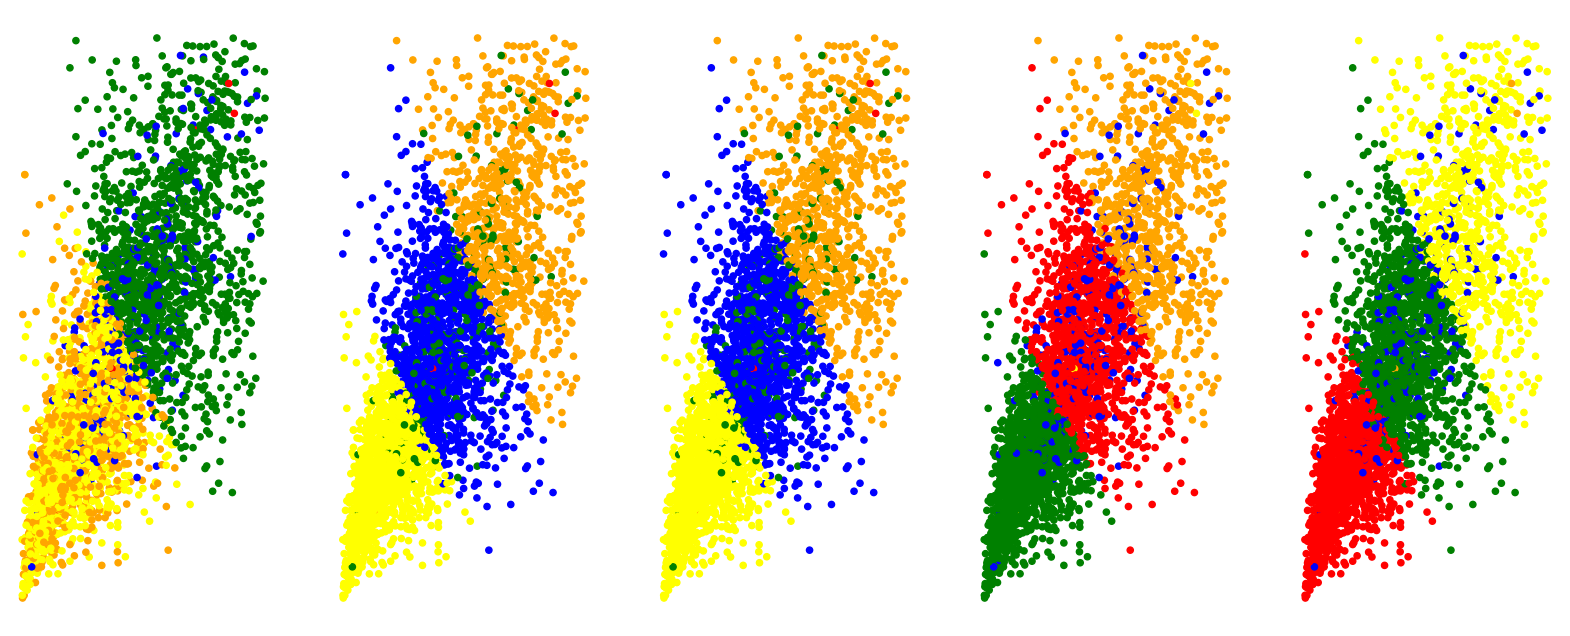

In [57]:
fig, ax = plt.subplots(1,5, figsize = (20,8))
j = 0
for v in km.values():
  colores = []
  for i in v.labels_:
    if i == 0:
      colores.append('blue')
    elif i == 1:
      colores.append('green')
    elif i == 2:
      colores.append('red')
    elif i == 3:
      colores.append('orange')
    else:
      colores.append('yellow')
  ventas2.plot(kind = 'scatter', x = 'cant_prom_operacion', y = 'gasto_prom_operacion', c = colores, ax = ax[j])
  ax[j].set_axis_off()
  j += 1

**¿Cómo sabemos que parámetros elegir?**

Como todo algorimto de aprendizaje automático estamos minimizando una función, por lo tanto el algoritmo que tenga el valor mínimo de la función de costo es el que vamos a adoptar como más óptimo.

 La función de costo se conococe como **inercia** o **la suma de los cuadrados de las diferencias intraclusters**

\begin{equation}
WSS = \sum_{k=1}^{K}\sum_{i\in k}||x_i-\mu_k||_2^2
\end{equation}


In [58]:
for k,v in km.items():
  print("para el modelo {} la inercia fue de {}".format(k, v.inertia_))

para el modelo km1 la inercia fue de 6533.228990424003
para el modelo km2 la inercia fue de 6167.63219058591
para el modelo km3 la inercia fue de 6167.63219058591
para el modelo km4 la inercia fue de 6169.645669937054
para el modelo km5 la inercia fue de 6166.271083904687


# ¿Cómo saber cuantos grupos utilizar?


Uno de los problemas que surge en el aprendizaje no supervisado es que no sabemos cual es la respuesta correcta. Sin embargo de antes de empezar el modelo tenemos que definir parámetros que no sabemos si son los que mejor rinden.

El más importante es el número de grupos en el cual yo quiero agrupar los datos, siguiendo lo planteado anteriormente la forma de elegirlos sería minimizando la inercia. ¿Es esto correcto?

La respuesta es que no porque el $WSS$ se hace $0$ cuando $K=n$ y esto significaría que no ha aprendido nada.

Una de las técnicas utilizadas para definir es el gráfico de codo (**elbow plot**) en estos casos vamos a elegir la cantidad de grupos en los que la mejora en la inercia no sea tan notoria.


![Diagrama de clustering](https://github.com/cristiandarioortegayubro/BDS/blob/main/images/Clustering-001.png?raw=true)


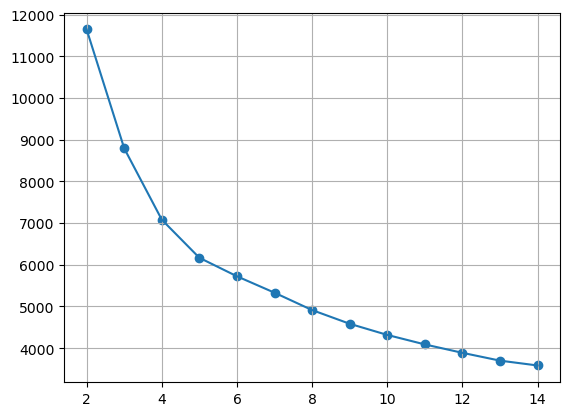

In [59]:
n_grups = range(2,15)

inercia = []
for i in n_grups:
  km_ = cl.KMeans(n_clusters = i, n_init = 10,init = "k-means++", random_state = 5464 )
  km_.fit(X)
  inercia.append(km_.inertia_)
plt.scatter(n_grups, inercia)
plt.plot(n_grups, inercia)
plt.grid()
#fig = px.line(x=n_grups, y=inercia, title='Inercia KMenas')
#fig.show()

En la práctica el punto de quiebre no es tan claro. Sin embargo, parece que la cantidad de 5 grupos es la óptima en estos casos. 

## Interpretación de resultados

In [93]:
rdos = ventas2[numericas].groupby(km['km5'].labels_).mean()
rdos = pd.concat([ventas2.groupby(km['km5'].labels_).count()[['CustomerID']],rdos]
                            , axis = 1 )
rdos

,CustomerID,gasto_prom_operacion,cant_prom_operacion,distintos_productos,cantidad_operaciones
0,255,282.539357,164.324213,234.776471,19.505882
1,1261,259.679813,148.008317,49.688343,3.942902
2,1495,131.545542,65.768804,28.533779,3.375920
3,6,330.740869,196.976136,1155.500000,167.500000
4,738,401.592284,254.231501,63.860434,3.913279


In [94]:
ventas2[categoricas].groupby(km['km5'].labels_).agg(lambda x: x.mode().iloc[0] if not x.empty else None)

,momento_dia,UK,84077 - WORLD WAR 2 GLIDERS ASSTD DESIGNS,84879 - ASSORTED COLOUR BIRD ORNAMENT,22492 - MINI PAINT SET VINTAGE,85123A - WHITE HANGING HEART T-LIGHT HOLDER
0,tarde,1,0,0,0,0
1,tarde,1,0,0,0,0
2,tarde,1,0,0,0,0
3,tarde,1,0,0,0,0
4,tarde,1,0,0,0,0


In [95]:
rdos = pd.concat([rdos,ventas2[categoricas].groupby(km['km5'].labels_).
                  agg(lambda x: x.mode().iloc[0] if not x.empty else None)], axis = 1 )

rdos

,CustomerID,gasto_prom_operacion,cant_prom_operacion,distintos_productos,cantidad_operaciones,momento_dia,UK,84077 - WORLD WAR 2 GLIDERS ASSTD DESIGNS,84879 - ASSORTED COLOUR BIRD ORNAMENT,22492 - MINI PAINT SET VINTAGE,85123A - WHITE HANGING HEART T-LIGHT HOLDER
0,255,282.539357,164.324213,234.776471,19.505882,tarde,1,0,0,0,0
1,1261,259.679813,148.008317,49.688343,3.942902,tarde,1,0,0,0,0
2,1495,131.545542,65.768804,28.533779,3.375920,tarde,1,0,0,0,0
3,6,330.740869,196.976136,1155.500000,167.500000,tarde,1,0,0,0,0
4,738,401.592284,254.231501,63.860434,3.913279,tarde,1,0,0,0,0


# Agrupamiento Aglomerativo o Jerárquico


Con la librería `scikitlearn` también tenemos la posibilidad de agrupar los datos de acuerdo a la técnica de árboles jerárquicos.

Dentro de los parámetros que tiene el método, los principales son:

**n_clusters**: Cantidad de grupos

**affinity**: Es la métrica usada para calcular las distancias entre los diferentes datos. Generalmente se usa la euclidiana.

**metric**: Es la métrica que se va usar en el enlace pueden ser varias pero si el enlace es "ward" entonces solo se acepta la euclidiana.

**linkage**: Puede ser "ward", "complete", "average", "single" . Es la forma en que se van a ir conectando los datos.

La forma de trabajo con `Scikit-learn` es la misma que con `K-means`. En general es muy similar a la forma de trabajo que tiene la librería.


In [60]:
aglo = cl.AgglomerativeClustering(n_clusters = 5)
aglo.fit(X)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",5
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


In [61]:
aglo.labels_

array([1, 0, 0, ..., 0, 0, 3], shape=(3755,))

In [62]:
ventas2[numericas].groupby(aglo.labels_).mean()

,gasto_prom_operacion,cant_prom_operacion,distintos_productos,cantidad_operaciones
0,157.323456,84.367059,35.007184,3.857280
1,320.091459,195.420823,51.105903,3.692708
2,330.740869,196.976136,1155.500000,167.500000
3,284.746426,167.542306,243.640496,18.293388
4,473.386140,272.134557,80.082397,4.292135


In [63]:
n_grupos = 5

aglo = {"aglo1" : cl.AgglomerativeClustering(n_clusters = n_grupos,  metric = 'euclidean', linkage = 'ward'),
        "aglo2" : cl.AgglomerativeClustering(n_clusters = n_grupos,  metric = 'euclidean', linkage = 'single'),
        "aglo3" : cl.AgglomerativeClustering(n_clusters = n_grupos,  metric = 'euclidean', linkage = 'complete'),
        "aglo4" : cl.AgglomerativeClustering(n_clusters = n_grupos,  metric = 'euclidean', linkage = 'average'),
        "aglo5" : cl.AgglomerativeClustering(n_clusters = n_grupos,  metric = 'cosine', linkage = 'average')
    }

for v in aglo.values():
  v.fit(X)

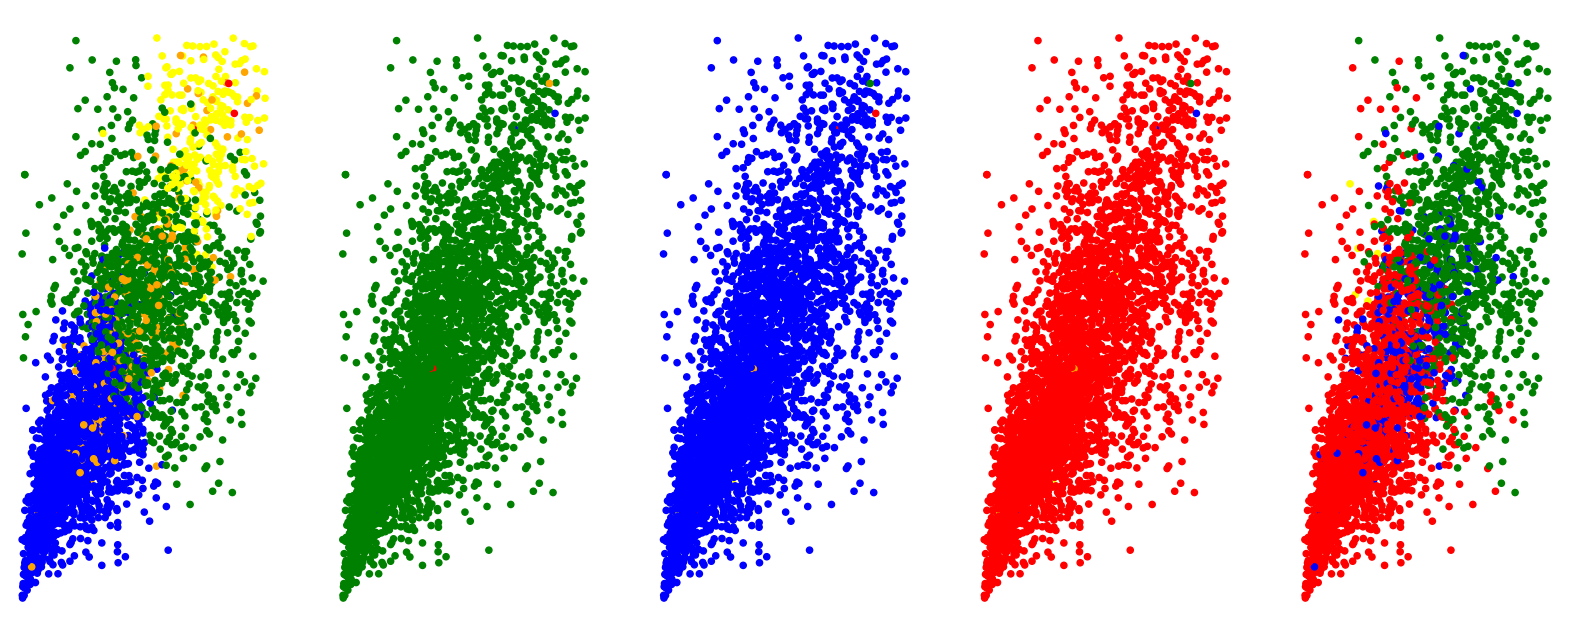

In [64]:
fig, ax = plt.subplots(1,5, figsize = (20,8))
j = 0
for v in aglo.values():
  colores = []
  for i in v.labels_:
    if i == 0:
      colores.append('blue')
    elif i == 1:
      colores.append('green')
    elif i == 2:
      colores.append('red')
    elif i == 3:
      colores.append('orange')
    else:
      colores.append('yellow')
  ventas2.plot(kind = 'scatter', x = 'cant_prom_operacion', y = 'gasto_prom_operacion', c = colores, ax = ax[j])
  ax[j].set_axis_off()
  j += 1

Considerando las dos variables como para el caso de `K-means` se puede ver que la forma que tiene de agrupar es diferente.

Por lo general este tipo de métodos suele identificar de forma más clara los **outlier** y los separa en grupos diferentes. Esto se debe a que si están muy separados se van a conectar entre ellos primero, pero luego van a tardar en unirse al resto.

 Esto hace que haya muchos grupos con pocas observaciones. Funciona bien con muchos datos y muchos grupos, `K-means` no tiende a funcionar muy bien cuando son muchos grupos.


## Interpretación



In [102]:
rdos2 = ventas2[numericas].groupby(aglo['aglo1'].labels_).mean()
rdos2 = pd.concat([ventas2.groupby(aglo['aglo1'].labels_).count()[['CustomerID']],rdos2]
                            , axis = 1 )
rdos2

,CustomerID,gasto_prom_operacion,cant_prom_operacion,distintos_productos,cantidad_operaciones
0,3746,238.117363,137.256311,56.500267,4.705019
1,2,332.176588,209.645017,1781.500000,236.000000
2,3,360.463066,209.090307,679.666667,121.333333
3,1,238.702840,135.295858,1331.000000,169.000000
4,3,183.943287,108.743359,220.666667,85.333333


In [103]:
ventas2[categoricas].groupby(aglo['aglo1'].labels_).agg(lambda x: x.mode().iloc[0])

,momento_dia,UK,84077 - WORLD WAR 2 GLIDERS ASSTD DESIGNS,84879 - ASSORTED COLOUR BIRD ORNAMENT,22492 - MINI PAINT SET VINTAGE,85123A - WHITE HANGING HEART T-LIGHT HOLDER
0,tarde,1,0,0,0,0
1,tarde,0,0,0,0,0
2,tarde,1,0,0,0,0
3,tarde,1,0,0,0,0
4,tarde,1,0,0,0,0


# Métricas de rendimiento


Una de las dificultades que presenta el aprendizaje no supervisado es que no existe algún método que funcione mejor que otro, además, la modificación de los denominados hiperparámetros afecta sensiblemente el rendimiento del algoritmo empleado. Por lo tanto, se busca comparar varias metodologías que se usan habitualmente para la detección de clústeres, e incluso comparar varias veces la misma metodología, pero variando los hiperparámetros.

Para esto hay que evaluarlos usando métricas de rendimineto.

 Como hemos visto una de las métricas para evaluar el algoritmo es la inercia.  El problema que tiene esta que nos da un valor que no se puede comparar o no se puede medir que tan lejos estamos de lo óptimo.

Una forma de subsanar eso es usando el ratio que surge entre la suma de cuadrados entre clusters y la suma de cuadrados total.

\begin{equation}
RBTSS = \frac{BSS}{TSS}
\end{equation}

De esta manera nos va dar un valor que se encuentra entre 0 y 1 siendo 1 el valor óptimo.

 Esta métrica no se encuentra establecida dentro de la librería `Scikit- learn`, por lo tanto si se quiere utilizar es necesario programarla


In [65]:
import numpy as np
def dist(x,y):
    x = np.array(x)
    y = np.array(y)
    return np.sum((x-y)**2)

def wss(X):
    X = np.array(X)
    C = np.mean(X,axis = 0)
    filas = X.shape[0]
    rdo = []
    for i in range(filas-1):
        x = X[i,:]
        #r = []
        r = dist(x,C)
        #for j in range(1,filas):
        #    y = X[j,:]
        #    r.append(dist(x,y))
        rdo.append(r)
    return np.sum(rdo)

def SSD(X, grupos):
    X = np.array(X)
    grupos = np.array(grupos)
    g = np.unique(grupos)
    WSS = []
    for i in g:
        x = X[grupos == i]
        WSS.append(wss(x))
    TSS = wss(X)
    BSS = TSS-np.sum(WSS)
    RBTSS = BSS/TSS
    return {'TSS': TSS, 'WSS': np.sum(WSS)/len(WSS), 'BSS': BSS, 'RBTSS':RBTSS}

In [66]:
SSD(X, aglo['aglo5'].labels_)

{'TSS': np.float64(16503.726778823457),
 'WSS': np.float64(2015.6081165663618),
 'BSS': np.float64(6425.686195991648),
 'RBTSS': np.float64(0.3893475868878709)}

De acuerdo al diccionario de metodologías jerárquicas ahora podemos calcular esta métrica para cada una. Y por supuesto también podemos compararlo con el método `k-means` calculado previamente...


In [67]:
for k, v in aglo.items():
  rbtss = round(SSD(X, v.labels_)['RBTSS'],2)
  print("Para el método {} el RBTSS fue de {}".format(k,rbtss))

Para el método aglo1 el RBTSS fue de 0.59
Para el método aglo2 el RBTSS fue de 0.21
Para el método aglo3 el RBTSS fue de 0.22
Para el método aglo4 el RBTSS fue de 0.22
Para el método aglo5 el RBTSS fue de 0.39


Ahora lo calculamos para el modelo `K-means` que habíamos seleccionado previamente.


In [68]:
SSD(X, km['km5'].labels_)

{'TSS': np.float64(16503.726778823457),
 'WSS': np.float64(1230.8469774020177),
 'BSS': np.float64(10349.491891813368),
 'RBTSS': np.float64(0.6271002925892584)}

De acuerdo a está métrica de rendimiento nos conviene seguir eligiendo el modelo `K-Means` con las caracaterísticas del Km5


## Coeficiente de Siluetas


Otra métrica muy utilizada en la literatura es el coeficiete de siluetas. Este tiene ventajas sobre la suma de cuadrados de las desviaciones porque castiga el exceso de grupos.

\begin{equation}
s=\frac{b-a}{max(a,b)}
\end{equation}

siendo $a$ la distancia media entre una observación y todos los elementos de su grupo y $b$ la distancia media entre una observación y todos los elementos de su grupo más próximo. Este coeficiente va de -1 a 1 siendo el valor de 1 el que mejor rendimiento presenta.


In [69]:
from sklearn.metrics import silhouette_score, silhouette_samples

rdos = {}

for k,v in km.items():
  sil = silhouette_score(X, v.labels_)
  rdos[k] = sil

for k,v in aglo.items():
  sil = silhouette_score(X, v.labels_)
  rdos[k] = sil

pd.DataFrame(rdos, index = ['sil']).T.sort_values('sil')

,sil
aglo5,0.103647
km1,0.233477
km3,0.249612
km2,0.249612
km5,0.250886
km4,0.252878
aglo1,0.273840
aglo3,0.741657
aglo4,0.741657
aglo2,0.839283


El coeficiente de siluetas en realidad se calcula unidad por unidad, esto permite definir  que unidad se encuentra bien asignada al grupo y cual esta mal asignada.

Si el coeficiente es positivo, esto indica que el punto se encuentra más cerca de todos los vecinos de su mismo grupo que del grupo vecino más cercano. Por lo tanto está bien asignado.

Si el coeficiente es 0, indica que la asignación es difusa, porque están a la misma distancia entre este grupo y el vecino.

Si el coeficiente es negativo, directamente indica una mala asignación al grupo.

 Una forma de mirar esto más fácil es con el gráfico de siluetas. Este gráfico nos va permitir observar la cantidad de unidades asignadas a cada grupo, cuantas unidades están bien asignadas y  cuantas están mal asignadas.


In [70]:
#importamos el mapa de colores
from matplotlib import cm

#Creamos una función que realiza el gráfico de siluetas
def graficoSiluetas(X, met):
  labels = np.unique(met.labels_) # define los niveles de los grupos
  n_clusters = labels.shape[0] #cantidad de grupos
  siluetas = silhouette_samples(X, met.labels_) #aplica el coef. de siluetas  uno a uno
  y_ax_lower, y_ax_upper = 0,0  # el lower define el piso en el que va empezar el grupo y el upper en dónde finaliza
  yticks = []
  for i, c in enumerate(labels):
    c_siluetas = siluetas[met.labels_ == c] #determina los valores del coef. para cada grupo
    c_siluetas.sort()
    y_ax_upper += len(c_siluetas)
    color = cm.jet(float(i)/n_clusters)
    plt.barh(range(y_ax_lower, y_ax_upper),
            c_siluetas,
            height = 1,
            edgecolor = 'none',
            color = color
            )
    yticks.append((y_ax_lower + y_ax_upper)/2)
    y_ax_lower += len(c_siluetas)

  silueta_prom = np.mean(siluetas)
  plt.axvline(silueta_prom, color = 'red', linestyle = "--")
  plt.yticks(yticks, labels+1)
  plt.ylabel('Grupo')
  plt.xlabel('Coeficiente de siluetas')
  plt.show()

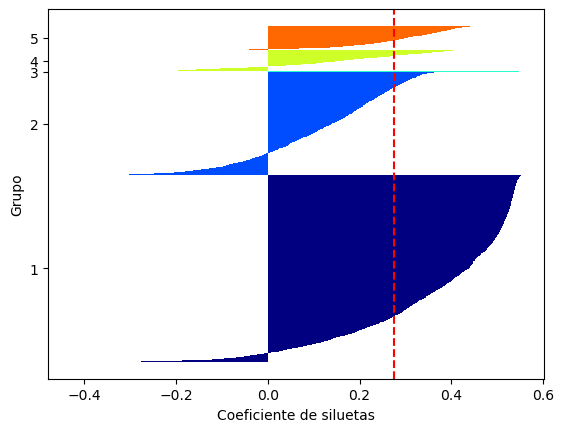

In [71]:
graficoSiluetas(X, aglo['aglo1'])

Para el método jerarquico 1 que armamos podemos ver que el grupo 4 casi no tiene asignada unidades que el grupo 2 y 3 presentan un alto porcentaje de unidades mal asignadas y que el grupo 5 parece ser el que mejor asginación presenta.


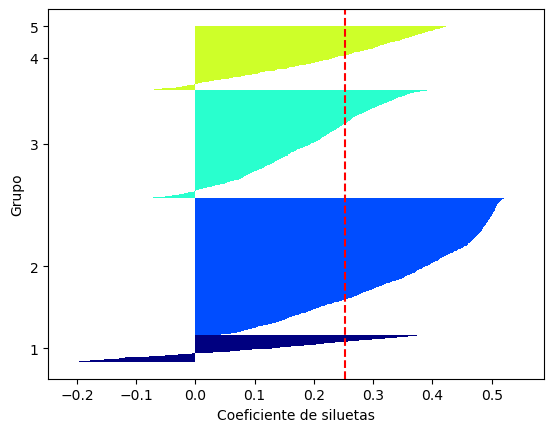

In [72]:
graficoSiluetas(X, km['km4'])

Para el `K-means` con los parámetros de km5 vemos que tenemos muy bien asignados los grupos 2 y 3. El grupo 5 se encuentra con muy pocas unidades y un gran porcentaje mal asignada y altos porcentajes de mal asignación para el grupo 4 y el grupo 1.


# Conclusiones


En este colab nosotros:

- Utilizamos algunos métodos de clustering que ofrece la librería `scikit-learn`.

- Seleccionamos los parámetros óptimos en un algoritmo `K-means` y en un agrupamiento jerárquico.

- Aprendimos una técnica para seleccionar el número óptimo de grupos de un algoritmo.

- Evaluamos los clusters obtenidos utilizando las métricas de rendimiento más comunes que existen actualmente.
